Load Dataset from DeepLoc


In [1]:
import pandas as pd

df = pd.read_csv("https://services.healthtech.dtu.dk/services/DeepLoc-2.0/data/Swissprot_Train_Validation_dataset.csv")

In [2]:
df.head()

,Unnamed: 0,ACC,Kingdom,Partition,Membrane,Cytoplasm,Nucleus,Extracellular,Cell membrane,Mitochondrion,Plastid,Endoplasmic reticulum,Lysosome/Vacuole,Golgi apparatus,Peroxisome,Sequence
0,0,Q28165,Metazoa,4,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MAAAAAAAAAAGAAGGRGSGPGRRRHLVPGAGGEAGEGAPGGAGDY...
1,1,Q86U42,Metazoa,4,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MAAAAAAAAAAGAAGGRGSGPGRRRHLVPGAGGEAGEGAPGGAGDY...
2,2,Q0GA42,Metazoa,3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,MAAAAAAAAALGVRLRDCCSRGAVLLLFFSLSPRPPAAAAWLLGLR...
3,3,P82349,Metazoa,1,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,MAAAAAAAAATEQQGSNGPVKKSMREKAVERRNVNKEHNSNFKAGY...
4,4,Q7L5N1,Metazoa,1,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MAAAAAAAAATNGTGGSSGMEVDAAVVPSVMACGVTGSVSVALHPL...


Extract Cytoplasm Presence Data

In [3]:
import numpy as np

y_data = df["Cytoplasm"].to_list()
y = 5
print(f"First {y} Entries: {y_data[:y]}")

First 5 Entries: [1.0, 1.0, 0.0, 1.0, 1.0]


Extract Protein Sequences

In [4]:
x_data = df["Sequence"].to_list()
x = 4
print(f"{x}th Entries: {x_data[x]}")

4th Entries: MAAAAAAAAATNGTGGSSGMEVDAAVVPSVMACGVTGSVSVALHPLVILNISDHWIRMRSQEGRPVQVIGALIGKQEGRNIEVMNSFELLSHTVEEKIIIDKEYYYTKEEQFKQVFKELEFLGWYTTGGPPDPSDIHVHKQVCEIIESPLFLKLNPMTKHTDLPVSVFESVIDIINGEATMLFAELTYTLATEEAERIGVDHVARMTATGSGENSTVAEHLIAQHSAIKMLHSRVKLILEYVKASEAGEVPFNHEILREAYALCHCLPVLSTDKFKTDFYDQCNDVGLMAYLGTITKTCNTMNQFVNKFNVLYDRQGIGRRMRGLFF


Extract Features: Amino acid normalized frequency count and sequence length

In [5]:
amino_acids = np.array(["A", "R", "N", "D", "C", "Q", "E", "G", "H", "I","L", "K", "M", "F", "P","S", "T", "W","Y","V"])

features = []
for seq in x_data: 
    if seq == " ":
        continue
    seq_length = len(seq)
    feature_vector = [seq_length]
    for amino in amino_acids:
        feature_vector.append(seq.count(amino)/seq_length)
    features.append(feature_vector)


print(f"First Entry: {features[:2]}")

First Entry: [[306, 0.11437908496732026, 0.0915032679738562, 0.03594771241830065, 0.032679738562091505, 0.006535947712418301, 0.013071895424836602, 0.13398692810457516, 0.13071895424836602, 0.013071895424836602, 0.032679738562091505, 0.049019607843137254, 0.032679738562091505, 0.0196078431372549, 0.026143790849673203, 0.09477124183006536, 0.06862745098039216, 0.029411764705882353, 0.0032679738562091504, 0.032679738562091505, 0.0392156862745098], [306, 0.11437908496732026, 0.0915032679738562, 0.032679738562091505, 0.032679738562091505, 0.006535947712418301, 0.013071895424836602, 0.13398692810457516, 0.13071895424836602, 0.013071895424836602, 0.032679738562091505, 0.049019607843137254, 0.032679738562091505, 0.0196078431372549, 0.026143790849673203, 0.09803921568627451, 0.06862745098039216, 0.029411764705882353, 0.0032679738562091504, 0.032679738562091505, 0.0392156862745098]]


In [6]:
nsamples =  len(x_data)
indices = np.arange(nsamples)
np.random.shuffle(indices)

train_split = int(nsamples*0.7)
test_split = int(nsamples*0.2) + train_split
train_idx, test_idx, validation_idx = indices[:train_split], indices[train_split:test_split], indices[test_split:]

print(f"train, test: {train_idx}")

train, test: [23712 25060  8207 ... 22671  2664 18938]


Data splitting for Testing (70%), Training (20%), and Validation (10%)

In [7]:

X = np.array(features)
y = np.array(y_data)

X_train, y_train = X[train_idx], y[train_idx]

X_test, y_test = X[test_idx], y[test_idx]
    
X_valid, y_valid = X[validation_idx], y[validation_idx]


print(X.shape)
print(X_train.shape)
print(X_test.shape)
print(X_valid.shape)
print(f"Y train_shape: {y_train.shape}")

(28303, 21)
(19812, 21)
(5660, 21)
(2831, 21)
Y train_shape: (19812,)


Standardization using Z-score

In [8]:
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)
std[std == 0] = 1

X_train = (X_train - mean)/std
print(X_train)
X_test = (X_test - mean)/std

X_valid = (X_valid - mean)/std


[[-0.58928637 -0.06843109 -0.40824918 ... -0.05477084  0.08349153
   1.16152701]
 [-0.79532444  0.15677588 -1.64259415 ... -0.64832539  2.34572991
   0.0086715 ]
 [ 2.8709413  -0.1851415  -0.43508588 ...  1.18592093 -0.75117697
  -0.49876322]
 ...
 [ 0.15608667 -0.08332969 -0.39641965 ... -0.09257237 -0.95831109
  -0.09758856]
 [-0.84986393  0.71185905 -1.81215722 ...  0.3471872   1.10833478
  -0.12034175]
 [-0.39940814 -1.14863034 -1.34186907 ... -1.03789185  1.31125876
  -0.16733527]]


In [9]:
import importlib
import protein_classifier

importlib.reload(protein_classifier)
from protein_classifier import ProteinClassifier

model = ProteinClassifier(x_train=X_train, y_train=y_train, x_test=X_test, y_test=y_test, x_valid=X_valid, y_valid=y_valid)

losses = model.train_cross_entropy()


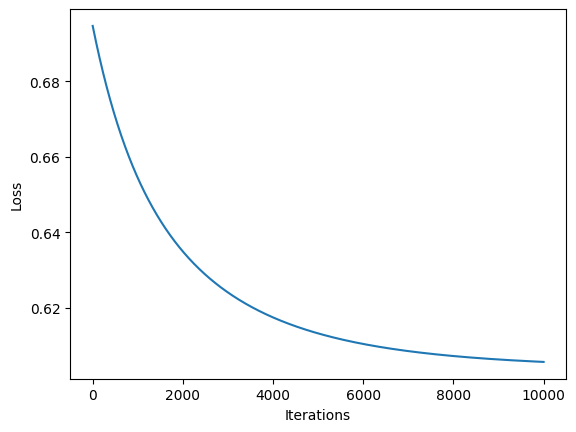

In [10]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()



In [14]:
y_prob = model.predict_proba(X_valid)
y_pred = (y_prob >= 0.5)
correct = (y_pred == y_valid)
accuracy = np.mean(correct)

print(f"Accuracy: {accuracy}")

Accuracy: 0.6580713528788414


Model Evaluation

In [15]:
print("train positive rate:", np.mean(y_train))
print("valid positive rate:", np.mean(y_valid))
print("test positive rate:", np.mean(y_test))

print("unique predictions:", np.unique(y_pred))
print("unique true labels:", np.unique(y_test))

baseline_acc = np.mean(y_test == 0)
print("always predict 0 accuracy:", baseline_acc)

y_prob = model.predict(X_test)
print(np.min(y_prob), np.max(y_prob), np.mean(y_prob))


train positive rate: 0.3508479709267111
valid positive rate: 0.35605793006004943
test positive rate: 0.33763250883392226
unique predictions: [False  True]
unique true labels: [0. 1.]
always predict 0 accuracy: 0.6623674911660777
False True 0.1390459363957597


Evaluation Metrics

In [17]:
y_true = y_valid  

TP = np.sum((y_pred == 1) & (y_true == 1))
TN = np.sum((y_pred == 0) & (y_true == 0))
FP = np.sum((y_pred == 1) & (y_true == 0))
FN = np.sum((y_pred == 0) & (y_true == 1))

accuracy = (TP + TN) / len(y_true)
recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0 

f1_score = 2 * (precision * recall)/(precision + recall)

print("TP:", TP, "TN:", TN, "FP:", FP, "FN:", FN)
print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("F1 score:", f1_score)


TP: 204 TN: 1659 FP: 164 FN: 804
Accuracy: 0.6580713528788414
Recall: 0.20238095238095238
Precision: 0.5543478260869565
F1 score: 0.29651162790697677


In [ ]:
best_f1 = 0
best_t = 0

f1_scores = []
thresholds = []

for t in np.linspace(0.1, 0.9, 50):
    y_pred = (y_prob >= t)

    TP = np.sum((y_pred == 1) & (y_true == 1))
    FP = np.sum((y_pred == 1) & (y_true == 0))
    FN = np.sum((y_pred == 0) & (y_true == 1))

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0

    if precision + recall > 0:
        f1 = 2 * (precision * recall) / (precision + recall)
    else:
        f1 = 0
    
    f1_scores.append(f1)
    thresholds.append(t)

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best threshold:", best_t)
print("Best F1:", best_f1)

Best threshold: 0.1
Best F1: 0.5992347363167526


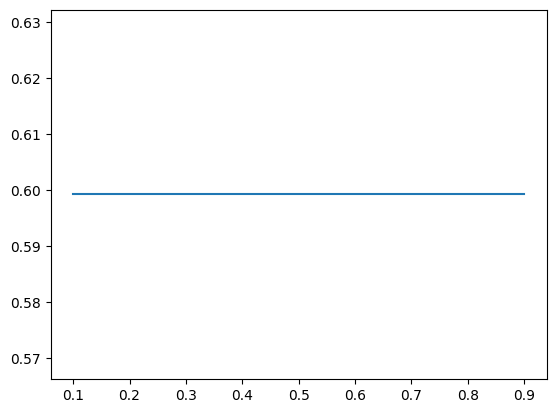

In [ ]:
plt.plot(thresholds, f1_scores)

In [19]:
print(np.min(y_prob), np.max(y_prob), np.mean(y_prob))
print(y_prob[:10])

False True 0.1390459363957597
[ True False False  True False False False False False False]
